# 05 - Transfer Learning with ResNet18 (PyTorch, GPU)

This notebook trains a **ResNet18 transfer learning model** on **Dataset 1**.

## Workflow
1. Set paths and hyperparameters
2. Load train / val / test datasets
3. Use a pretrained ResNet18 backbone
4. Replace the final classification layer for 50 classes
5. Train on GPU if available
6. Save the best model and reports
7. Evaluate on the test set
8. Visualize results

## Notes
- This notebook is designed for **PyTorch + GPU**
- It keeps output file names clear and easy to distinguish
- It is suitable as the **second major model** for Assignment 2


In [2]:
# Imports
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [3]:
# Optional: display Chinese class names correctly on Windows
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
# Paths
PROJECT_ROOT = Path(r"I:\DeepLearning\ChineseHerb_Identify")

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "herb50_dataset_1" / "split_dataset"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
MODELS_DIR = PROJECT_ROOT / "models" / "transfer_learning"

for p in [FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)

TRAIN_DIR: I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\train
VAL_DIR  : I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\val
TEST_DIR : I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\test


In [6]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type != "cuda":
    print("WARNING: GPU is not being used. Check your PyTorch installation and CUDA setup.")

Using device: cuda


In [7]:
# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 45
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0   # Safer for Windows notebook
PATIENCE = 5
FREEZE_BACKBONE = False

print("IMG_SIZE =", IMG_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)
print("EPOCHS =", EPOCHS)
print("LEARNING_RATE =", LEARNING_RATE)
print("WEIGHT_DECAY =", WEIGHT_DECAY)
print("FREEZE_BACKBONE =", FREEZE_BACKBONE)

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 45
LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001
FREEZE_BACKBONE = False


In [8]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [9]:
# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 50
First 10 classes: ['乌梅', '侧柏叶', '北沙参块', '北沙参条', '半夏', '地龙', '夏枯草', '大血藤', '小茴香', '巴戟天']


In [10]:
# Save class mapping
transfer_resnet18_class_mapping_df = pd.DataFrame({
    "class_id": list(range(len(class_names))),
    "class_name_cn": class_names
})

transfer_resnet18_class_mapping_path = REPORTS_DIR / "transfer_resnet18_pytorch_class_mapping.csv"
transfer_resnet18_class_mapping_df.to_csv(transfer_resnet18_class_mapping_path, index=False, encoding="utf-8-sig")

print("Saved:", transfer_resnet18_class_mapping_path)
transfer_resnet18_class_mapping_df.head()

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_class_mapping.csv


,class_id,class_name_cn
0,0,乌梅
1,1,侧柏叶
2,2,北沙参块
3,3,北沙参条
4,4,半夏


In [11]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 779
Val batches  : 98
Test batches : 98


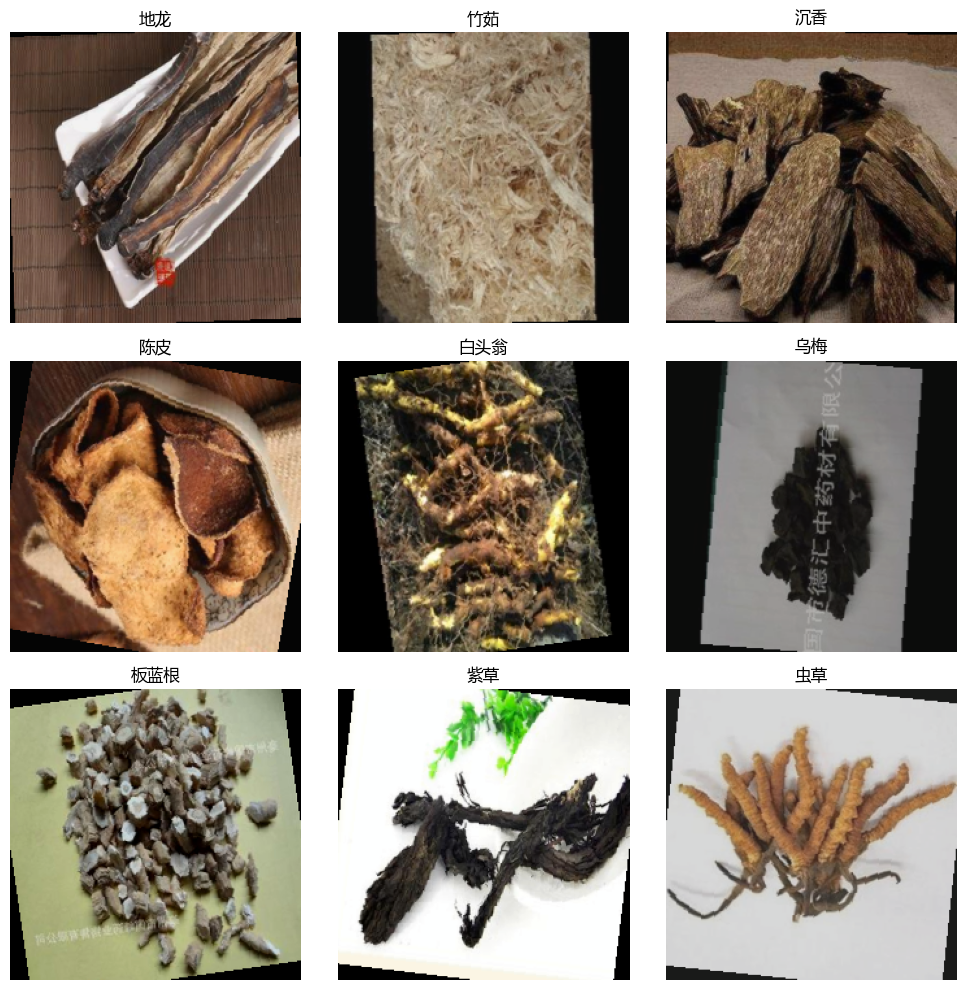

In [12]:
# Visualize a few training images
display_images, display_labels = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = display_images[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip((img * std) + mean, 0, 1)
    plt.imshow(img)
    plt.title(class_names[display_labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Build pretrained ResNet18 model
weights = ResNet18_Weights.DEFAULT
transfer_resnet18_model = models.resnet18(weights=weights)

if FREEZE_BACKBONE:
    for param in transfer_resnet18_model.parameters():
        param.requires_grad = False

in_features = transfer_resnet18_model.fc.in_features
transfer_resnet18_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

transfer_resnet18_model = transfer_resnet18_model.to(device)
transfer_resnet18_model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Palast/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 57.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, transfer_resnet18_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [15]:
# Training and validation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [16]:
# Train loop
transfer_resnet18_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

transfer_resnet18_best_val_acc = 0.0
transfer_resnet18_best_model_wts = copy.deepcopy(transfer_resnet18_model.state_dict())
transfer_resnet18_best_model_path = MODELS_DIR / "transfer_resnet18_pytorch_best_model.pth"

patience_counter = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        transfer_resnet18_model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, _, _ = evaluate(
        transfer_resnet18_model, val_loader, criterion, device
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    transfer_resnet18_history["train_loss"].append(train_loss)
    transfer_resnet18_history["train_acc"].append(train_acc)
    transfer_resnet18_history["val_loss"].append(val_loss)
    transfer_resnet18_history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if val_acc > transfer_resnet18_best_val_acc:
        transfer_resnet18_best_val_acc = val_acc
        transfer_resnet18_best_model_wts = copy.deepcopy(transfer_resnet18_model.state_dict())
        torch.save(transfer_resnet18_best_model_wts, transfer_resnet18_best_model_path)
        patience_counter = 0
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 60)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", transfer_resnet18_best_val_acc)
print("Best model saved to:", transfer_resnet18_best_model_path)

Epoch 1/45


  0%|          | 0/779 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

Train Loss: 1.3444 | Train Acc: 0.8212
Val   Loss: 0.9651 | Val   Acc: 0.9406
Learning Rate: 0.000100
Best model updated.
------------------------------------------------------------
Epoch 2/45


  0%|          | 0/779 [00:00<?, ?it/s]

...

  0%|          | 0/98 [00:00<?, ?it/s]

Train Loss: 0.7147 | Train Acc: 0.9998
Val   Loss: 0.7367 | Val   Acc: 0.9910
Learning Rate: 0.000013
No improvement. Patience: 4/5
------------------------------------------------------------
Epoch 27/45


  0%|          | 0/779 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

Train Loss: 0.7144 | Train Acc: 0.9998
Val   Loss: 0.7353 | Val   Acc: 0.9899
Learning Rate: 0.000013
No improvement. Patience: 5/5
------------------------------------------------------------
Early stopping triggered.
Best validation accuracy: 0.9913266945069065
Best model saved to: I:\DeepLearning\ChineseHerb_Identify\models\transfer_learning\transfer_resnet18_pytorch_best_model.pth


In [17]:
# Save training history
transfer_resnet18_history_df = pd.DataFrame(transfer_resnet18_history)
transfer_resnet18_history_path = REPORTS_DIR / "transfer_resnet18_pytorch_training_history.csv"
transfer_resnet18_history_df.to_csv(transfer_resnet18_history_path, index=False)

print("Saved:", transfer_resnet18_history_path)
transfer_resnet18_history_df.head()

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_training_history.csv


,train_loss,train_acc,val_loss,val_acc
0,1.344424,0.821160,0.965129,0.940572
1,0.938427,0.950744,0.876324,0.965949
2,0.864254,0.973706,0.839938,0.972374
3,0.830159,0.982678,0.815894,0.979923
4,0.808190,0.986893,0.821731,0.974141


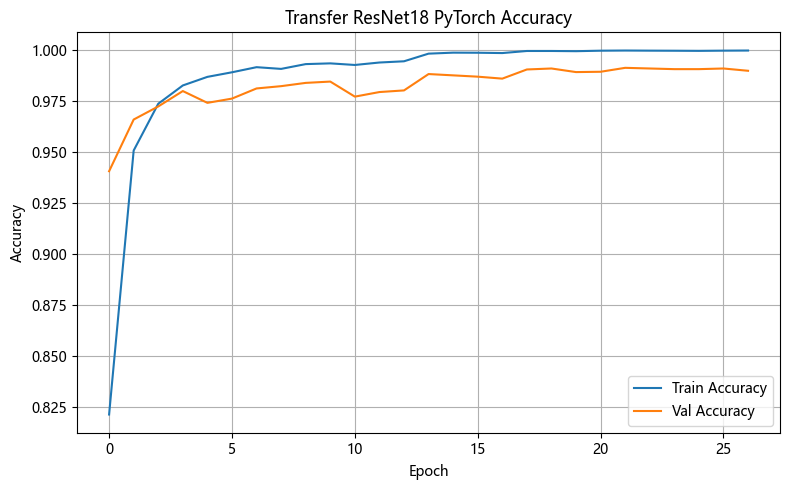

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_accuracy_curve.png


In [18]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(transfer_resnet18_history["train_acc"], label="Train Accuracy")
plt.plot(transfer_resnet18_history["val_acc"], label="Val Accuracy")
plt.title("Transfer ResNet18 PyTorch Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

transfer_resnet18_accuracy_curve_path = FIGURES_DIR / "transfer_resnet18_pytorch_accuracy_curve.png"
plt.savefig(transfer_resnet18_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", transfer_resnet18_accuracy_curve_path)

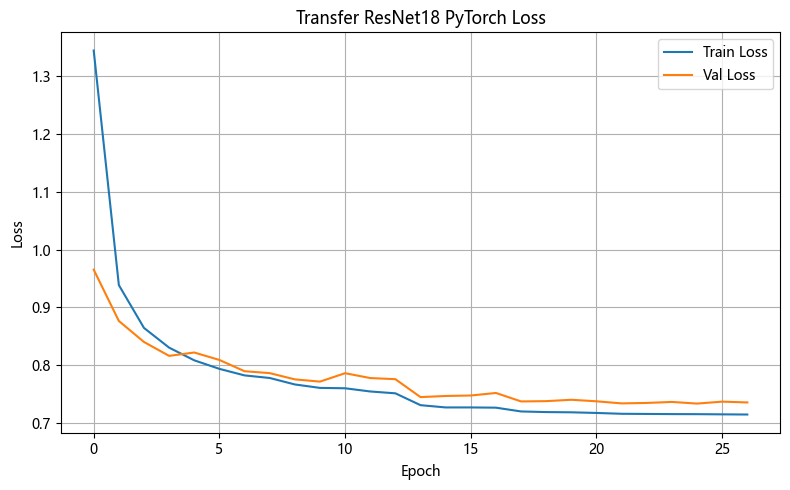

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_loss_curve.png


In [19]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(transfer_resnet18_history["train_loss"], label="Train Loss")
plt.plot(transfer_resnet18_history["val_loss"], label="Val Loss")
plt.title("Transfer ResNet18 PyTorch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

transfer_resnet18_loss_curve_path = FIGURES_DIR / "transfer_resnet18_pytorch_loss_curve.png"
plt.savefig(transfer_resnet18_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", transfer_resnet18_loss_curve_path)

In [20]:
# Load best weights before final testing
transfer_resnet18_model.load_state_dict(torch.load(transfer_resnet18_best_model_path, map_location=device))
transfer_resnet18_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
# Test evaluation
transfer_resnet18_test_loss, transfer_resnet18_test_acc, transfer_resnet18_y_true, transfer_resnet18_y_pred = evaluate(
    transfer_resnet18_model, test_loader, criterion, device
)

print(f"Transfer ResNet18 Test Loss: {transfer_resnet18_test_loss:.4f}")
print(f"Transfer ResNet18 Test Accuracy: {transfer_resnet18_test_acc:.4f}")

  0%|          | 0/98 [00:00<?, ?it/s]

Transfer ResNet18 Test Loss: 0.7286
Transfer ResNet18 Test Accuracy: 0.9944


In [22]:
# Classification report
transfer_resnet18_report_dict = classification_report(
    transfer_resnet18_y_true,
    transfer_resnet18_y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

transfer_resnet18_report_df = pd.DataFrame(transfer_resnet18_report_dict).transpose()
transfer_resnet18_report_path = REPORTS_DIR / "transfer_resnet18_pytorch_classification_report.csv"
transfer_resnet18_report_df.to_csv(transfer_resnet18_report_path, encoding="utf-8-sig")

print("Saved:", transfer_resnet18_report_path)
transfer_resnet18_report_df.head(10)

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_classification_report.csv


,precision,recall,f1-score,support
乌梅,1.000000,1.000000,1.000000,122.0
侧柏叶,1.000000,1.000000,1.000000,112.0
北沙参块,0.991870,1.000000,0.995918,122.0
北沙参条,0.990826,0.981818,0.986301,110.0
半夏,1.000000,0.982759,0.991304,116.0
地龙,0.984962,1.000000,0.992424,131.0
夏枯草,1.000000,1.000000,1.000000,110.0
大血藤,1.000000,1.000000,1.000000,132.0
小茴香,0.992308,0.992308,0.992308,130.0
巴戟天,1.000000,0.992806,0.996390,139.0


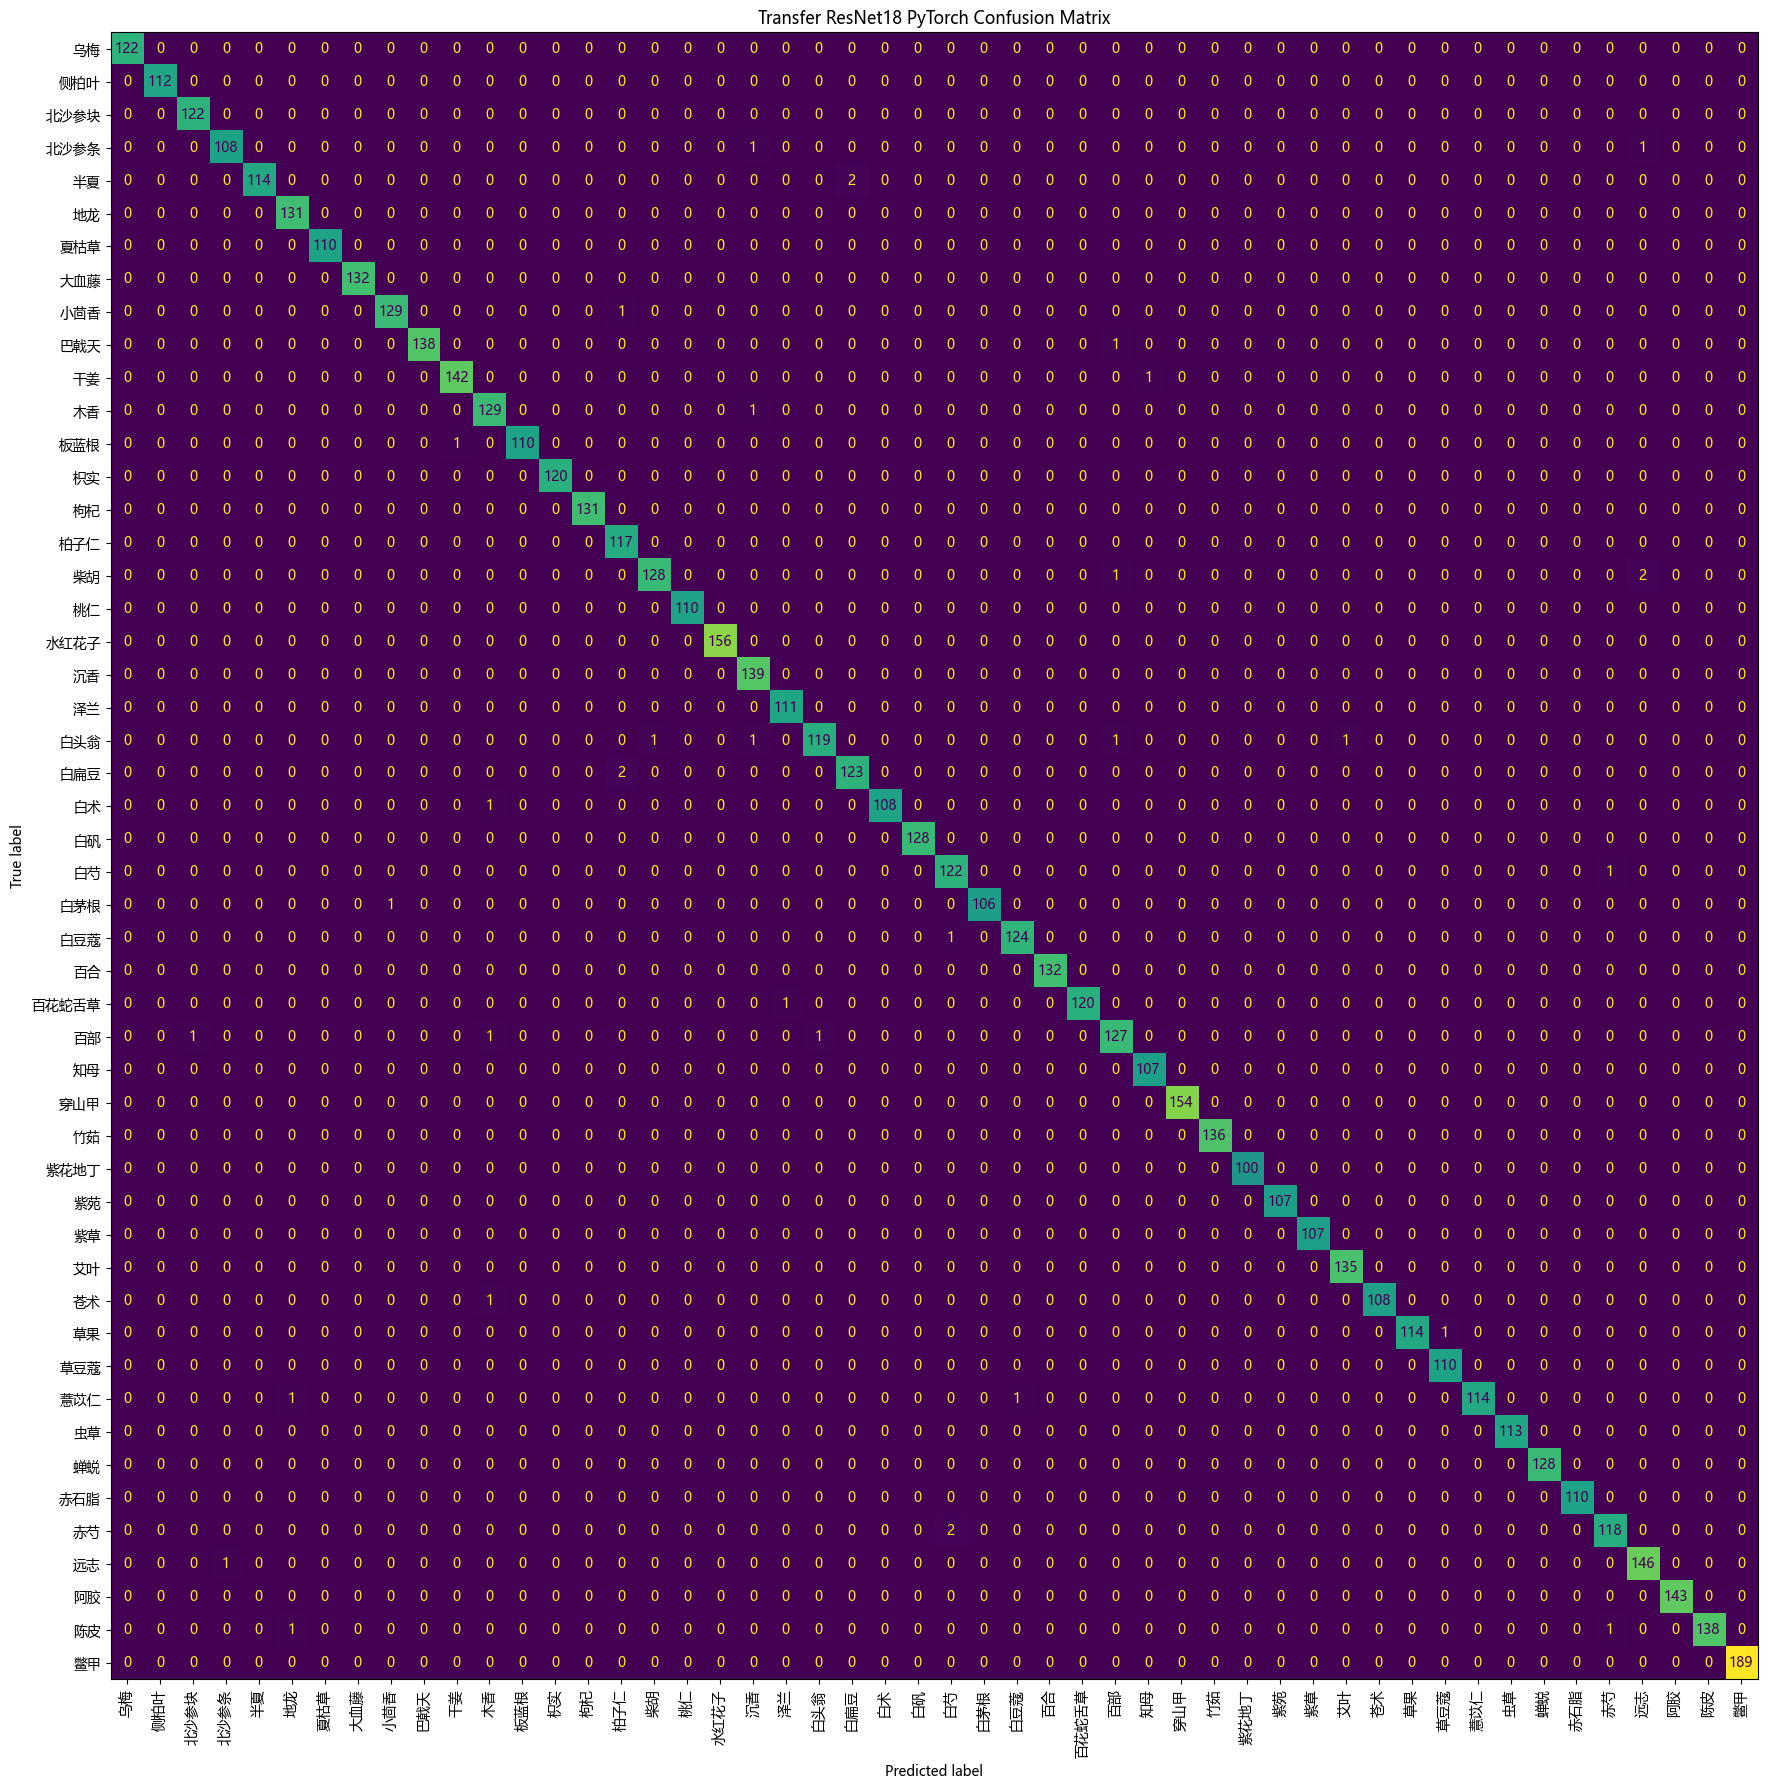

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_confusion_matrix.png


In [23]:
# Confusion matrix
transfer_resnet18_cm = confusion_matrix(transfer_resnet18_y_true, transfer_resnet18_y_pred)

fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=transfer_resnet18_cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Transfer ResNet18 PyTorch Confusion Matrix")
plt.tight_layout()

transfer_resnet18_confusion_matrix_path = FIGURES_DIR / "transfer_resnet18_pytorch_confusion_matrix.png"
plt.savefig(transfer_resnet18_confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", transfer_resnet18_confusion_matrix_path)

In [24]:
# Save summary
transfer_resnet18_summary = {
    "model_name": "transfer_resnet18_pytorch",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(transfer_resnet18_history["train_loss"]),
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "num_classes": num_classes,
    "best_val_accuracy": float(max(transfer_resnet18_history["val_acc"])),
    "best_val_loss": float(min(transfer_resnet18_history["val_loss"])),
    "test_loss": float(transfer_resnet18_test_loss),
    "test_accuracy": float(transfer_resnet18_test_acc),
    "freeze_backbone": FREEZE_BACKBONE,
    "device": str(device)
}

transfer_resnet18_summary_path = REPORTS_DIR / "transfer_resnet18_pytorch_summary.json"
with open(transfer_resnet18_summary_path, "w", encoding="utf-8") as f:
    json.dump(transfer_resnet18_summary, f, ensure_ascii=False, indent=4)

print("Saved:", transfer_resnet18_summary_path)
transfer_resnet18_summary

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_summary.json


{'model_name': 'transfer_resnet18_pytorch',
 'image_size': 224,
 'batch_size': 64,
 'epochs_requested': 45,
 'epochs_completed': 27,
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'num_classes': 50,
 'best_val_accuracy': 0.9913266945069065,
 'best_val_loss': 0.7333248069038967,
 'test_loss': 0.7285681651553692,
 'test_accuracy': 0.9943838254172015,
 'freeze_backbone': False,
 'device': 'cuda'}

## Notes for report writing

This notebook can be described as a **transfer learning model based on pretrained ResNet18**.

Main characteristics:
- pretrained on ImageNet
- final fully connected layer replaced for 50-class classification
- trained on GPU
- validation-based checkpointing
- data augmentation and normalization
- suitable for comparison against custom CNN models

This model serves as the **second major model family** in the project.
